In [1]:
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

In [2]:
model = joblib.load("venlix_model.pkl")

X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").squeeze()

In [3]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [4]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))

Accuracy : 1.0


In [5]:
precision = precision_score(y_test, y_pred)

print("Precision :", round(precision,4))

Precision : 1.0


In [6]:
recall = recall_score(y_test, y_pred)

print("Recall :", round(recall,4))

Recall : 1.0


In [7]:
f1 = f1_score(y_test, y_pred)

print("F1 Score :", round(f1,4))

F1 Score : 1.0


In [8]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8099
           1       1.00      1.00      1.00       649

    accuracy                           1.00      8748
   macro avg       1.00      1.00      1.00      8748
weighted avg       1.00      1.00      1.00      8748



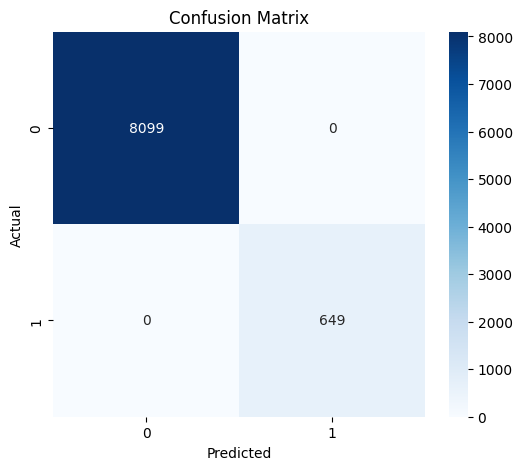

In [9]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

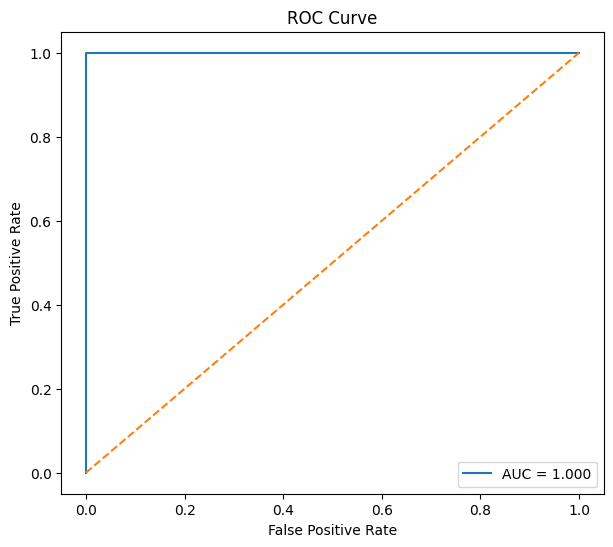

In [10]:
fpr,tpr,threshold = roc_curve(y_test,y_prob)

auc = roc_auc_score(y_test,y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr,tpr,label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

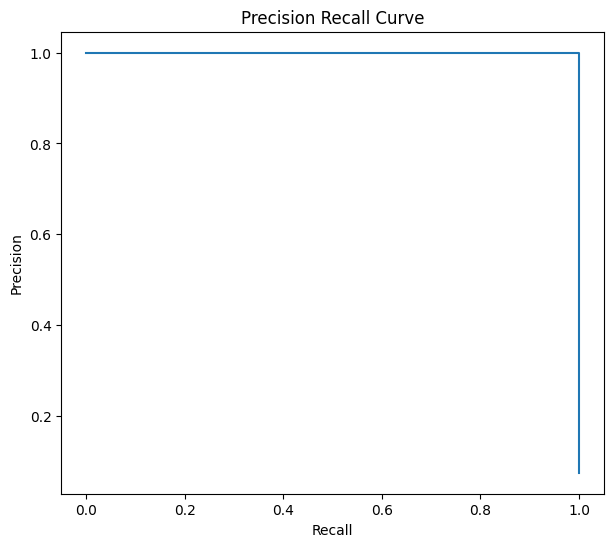

In [11]:
precision,recall,_ = precision_recall_curve(y_test,y_prob)

plt.figure(figsize=(7,6))

plt.plot(recall,precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [12]:
importance = pd.DataFrame({

    "Feature":X_test.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
19,risk_score,0.709035
14,customer_unavailability_history,0.076593
13,driver_on_time_rate,0.065861
6,Weather,0.041429
18,distance_km,0.040049
24,hour_of_day,0.026109
4,Drop_Latitude,0.013613
7,Traffic,0.010846
15,address_failure_history_rate,0.008121
10,Delivery_Time,0.002092


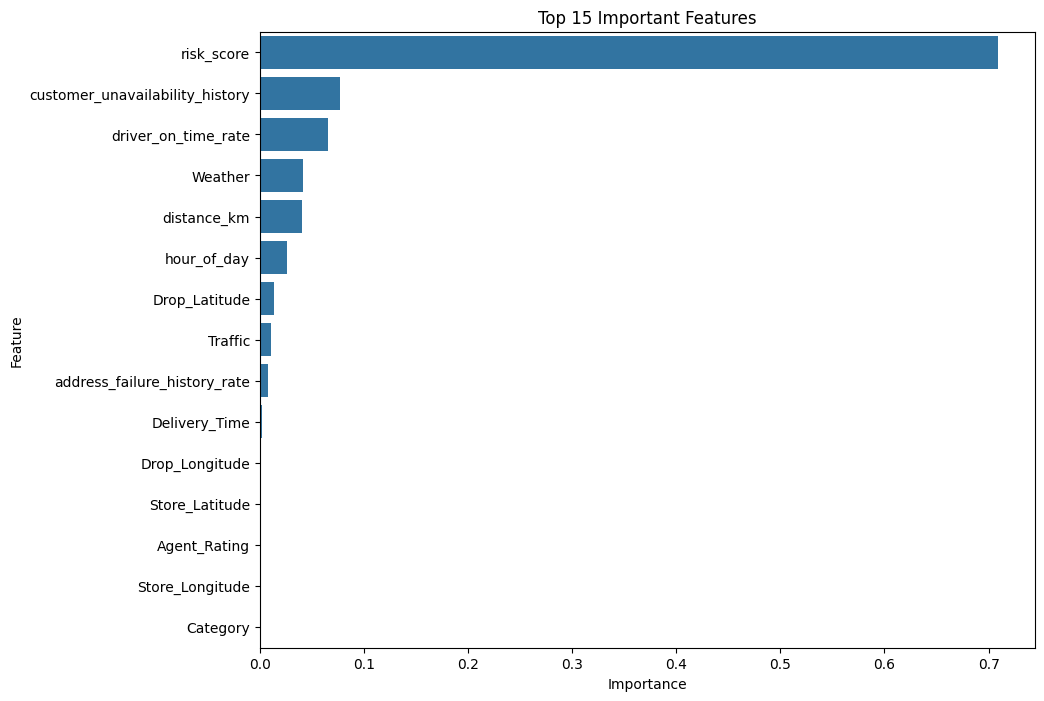

In [13]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title("Top 15 Important Features")

plt.show()

In [14]:
importance.head(10)

,Feature,Importance
19,risk_score,0.709035
14,customer_unavailability_history,0.076593
13,driver_on_time_rate,0.065861
6,Weather,0.041429
18,distance_km,0.040049
24,hour_of_day,0.026109
4,Drop_Latitude,0.013613
7,Traffic,0.010846
15,address_failure_history_rate,0.008121
10,Delivery_Time,0.002092


In [15]:
summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1,

        auc

    ]

})

summary

,Metric,Value
0,Accuracy,1.0
1,Precision,"[0.07418838591678098, 0.12063197026022304, 0.1..."
2,Recall,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
3,F1 Score,1.0
4,ROC AUC,1.0


In [16]:
summary.to_csv("model_metrics.csv",index=False)

importance.to_csv("feature_importance.csv",index=False)

print("Metrics Saved Successfully")

Metrics Saved Successfully


In [ ]:
%pip install shap